In [1]:
import sys
import os

project_root = os.path.abspath("../../")
if project_root not in sys.path:
    sys.path.append(project_root)


In [2]:
import pandas as pd
from data_mining import Dataset
from sklearn.model_selection import train_test_split
from damavand.damavand.utils import z_score_scaler
from experiments.supervised_anomaly_detection.classifier import VibrationFeatureExtractor, ContrastiveModel
from experiments.supervised_anomaly_detection.utils import ContrastiveDataset, VibrationClassificationDataset, create_balanced_contrastive_pairs, contrastive_loss, evaluate_model
import torch
import numpy as np
from torch import nn
from torch.utils.data import DataLoader

In [3]:
config = {
    "do_contrastive_pretraining": False,  # Set to False to skip contrastive representation learning
    "downsample_majority_class": False,  # Set to False to use the full, imbalanced training set
    "contrastive_epochs": 10,
    "classification_epochs": 15,
    "contrastive_lr": 0.001,
    "classification_lr": 0.0005,
    "batch_size_contrastive": 128,
    "batch_size_classify": 32,
}

In [4]:
dataset = Dataset(operations=["05", "06", "07", "08", "10", "11", "12"])
data = dataset.mine(win_len=1000, hop_len=1000)

/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP05/bad/M01_Aug_2019_OP05_000.h5  ---  (26793, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP05/bad/M01_Feb_2019_OP05_000.h5  ---  (29831, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP05/bad/M01_Feb_2019_OP05_001.h5  ---  (29621, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP05/bad/M01_Feb_2021_OP05_000.h5  ---  (30000, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP05/good/M01_Aug_2019_OP05_000.h5  ---  (46080, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP05/good/M01_Aug_2019_OP05_001.h5  ---  (41984, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP05/good/M01_Aug_2019_OP05_002.h5  ---  (47104, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP05/good/M01_Aug_2019_OP05_003.h5  ---  (43008, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/dat

In [5]:
data.keys()

dict_keys(['OP05', 'OP06', 'OP07', 'OP08', 'OP10', 'OP11', 'OP12'])

In [6]:
df = pd.concat([pd.concat(data[op]["0"]) for op in data.keys()]).reset_index(drop=True)
df

,0,1,2,3,4,5,6,7,8,9,...,994,995,996,997,998,999,machine,operation,state,file
0,-9.0,-50.0,-48.0,11.0,17.0,-11.0,-1.0,9.0,19.0,-29.0,...,33.0,37.0,40.0,33.0,19.0,21.0,M01,OP05,bad,M01_Aug_2019_OP05_000.h5
1,-3.0,27.0,-27.0,-39.0,7.0,9.0,54.0,33.0,23.0,-35.0,...,1188.0,1073.0,1138.0,897.0,1128.0,839.0,M01,OP05,bad,M01_Aug_2019_OP05_000.h5
2,1007.0,630.0,942.0,595.0,897.0,616.0,650.0,528.0,638.0,452.0,...,439.0,610.0,616.0,757.0,550.0,718.0,M01,OP05,bad,M01_Aug_2019_OP05_000.h5
3,519.0,573.0,368.0,435.0,203.0,199.0,187.0,54.0,11.0,-97.0,...,95.0,48.0,-39.0,-91.0,-27.0,-58.0,M01,OP05,bad,M01_Aug_2019_OP05_000.h5
4,35.0,99.0,-17.0,33.0,37.0,3.0,-52.0,-48.0,-33.0,-5.0,...,11.0,1.0,-23.0,15.0,25.0,29.0,M01,OP05,bad,M01_Aug_2019_OP05_000.h5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19702,-9.0,5.0,7.0,-40.0,23.0,56.0,-66.0,1.0,-11.0,-37.0,...,-5.0,-23.0,-9.0,-11.0,-17.0,-11.0,M01,OP12,good,M01_Feb_2021_OP12_008.h5
19703,-29.0,-21.0,-7.0,-13.0,-11.0,-7.0,-19.0,-9.0,-25.0,-9.0,...,-331.0,-419.0,-404.0,-162.0,-325.0,-244.0,M01,OP12,good,M01_Feb_2021_OP12_008.h5
19704,-322.0,-257.0,-324.0,-349.0,-484.0,-140.0,-345.0,-370.0,-368.0,-368.0,...,0.0,-7.0,-9.0,1.0,-31.0,-31.0,M01,OP12,good,M01_Feb_2021_OP12_008.h5
19705,-25.0,-33.0,-27.0,-44.0,-15.0,-13.0,1.0,-1.0,9.0,3.0,...,3.0,-23.0,-11.0,-17.0,-25.0,9.0,M01,OP12,good,M01_Feb_2021_OP12_008.h5


In [7]:
df_train, df_test = train_test_split(df, test_size=0.4, random_state=42)
df_train["state_encoded"] = df_train["state"].map({"good": 0, "bad": 1})
df_test["state_encoded"] = df_test["state"].map({"good": 0, "bad": 1})

In [8]:
if config["downsample_majority_class"]:
    print("Applying majority class downsampling to the training set...")
    # Separate classes based on encoded state
    df_good = df_train[df_train["state_encoded"] == 0]
    df_bad = df_train[df_train["state_encoded"] == 1]

    # Identify minority and majority sizes
    minority_size = min(len(df_good), len(df_bad))

    # Downsample both to match the minority size
    df_good_downsampled = df_good.sample(n=minority_size, random_state=42)
    df_bad_downsampled = df_bad.sample(n=minority_size, random_state=42)

    # Recombine
    df_train = pd.concat([df_good_downsampled, df_bad_downsampled]).sample(
        frac=1, random_state=42
    )
    print(f"New training set size: {len(df_train)} (Balanced)")
else:
    print("Using full, imbalanced training set.")


Using full, imbalanced training set.


In [9]:
x_train, y_train = df_train.iloc[:, :-5], df_train["state_encoded"]
x_test, y_test = df_test.iloc[:, :-5], df_test["state_encoded"]

x_train_scaled, x_test_scaled = z_score_scaler(x_train), z_score_scaler(x_test)
print(f"Train shape: {x_train_scaled.shape} | Test shape: {x_test_scaled.shape}")

# Verify final distribution
print("\nTrain class distribution:\n", y_train.value_counts())


Train shape: (11824, 1000) | Test shape: (7883, 1000)

Train class distribution:
 state_encoded
0    10529
1     1295
Name: count, dtype: int64


In [10]:
encoder = VibrationFeatureExtractor()
model = ContrastiveModel(encoder)

In [11]:
if config["do_contrastive_pretraining"]:
    print("\n>>> Starting Contrastive Representation Learning Loop...")
    X1, X2, Y_pairs = create_balanced_contrastive_pairs(x_train_scaled, y_train)
    contrastive_dataset = ContrastiveDataset(X1, X2, Y_pairs)
    contrastive_dataloader = DataLoader(
        contrastive_dataset, batch_size=config["batch_size_contrastive"], shuffle=True
    )

    model.set_mode("contrastive")
    optimizer_con = torch.optim.Adam(model.parameters(), lr=config["contrastive_lr"])

    for epoch in range(config["contrastive_epochs"]):
        epoch_loss = 0.0
        for x1_batch, x2_batch, y_batch in contrastive_dataloader:
            optimizer_con.zero_grad()
            z1 = model(x1_batch)
            z2 = model(x2_batch)
            loss = contrastive_loss(z1, z2, y_batch)
            loss.backward()
            optimizer_con.step()
            epoch_loss += loss.item()

        print(
            f"Contrastive Epoch [{epoch + 1}/{config['contrastive_epochs']}] - Loss: {epoch_loss / len(contrastive_dataloader):.4f}"
        )
else:
    print("\n>>> Skipping Contrastive Pretraining (disabled in config).")



>>> Skipping Contrastive Pretraining (disabled in config).


In [12]:
train_classify_dataset = VibrationClassificationDataset(x_train_scaled, y_train)
train_loader = DataLoader(
    train_classify_dataset, batch_size=config["batch_size_classify"], shuffle=True
)

model.set_mode("classify")
criterion = nn.CrossEntropyLoss()
optimizer_cls = torch.optim.Adam(model.parameters(), lr=config["classification_lr"])

model.train()
print("\n>>> Starting Downstream Classification Training...")
for epoch in range(config["classification_epochs"]):
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer_cls.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_cls.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100
    print(
        f"Classification Epoch [{epoch + 1}/{config['classification_epochs']}] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%"
    )



>>> Starting Downstream Classification Training...
Classification Epoch [1/15] - Loss: 0.1814 - Accuracy: 93.50%
Classification Epoch [2/15] - Loss: 0.0820 - Accuracy: 97.43%
Classification Epoch [3/15] - Loss: 0.0652 - Accuracy: 97.94%
Classification Epoch [4/15] - Loss: 0.0554 - Accuracy: 98.28%
Classification Epoch [5/15] - Loss: 0.0484 - Accuracy: 98.54%
Classification Epoch [6/15] - Loss: 0.0443 - Accuracy: 98.58%
Classification Epoch [7/15] - Loss: 0.0409 - Accuracy: 98.65%
Classification Epoch [8/15] - Loss: 0.0373 - Accuracy: 98.74%
Classification Epoch [9/15] - Loss: 0.0379 - Accuracy: 98.79%
Classification Epoch [10/15] - Loss: 0.0314 - Accuracy: 98.95%
Classification Epoch [11/15] - Loss: 0.0292 - Accuracy: 99.05%
Classification Epoch [12/15] - Loss: 0.0328 - Accuracy: 98.94%
Classification Epoch [13/15] - Loss: 0.0313 - Accuracy: 98.94%
Classification Epoch [14/15] - Loss: 0.0272 - Accuracy: 99.08%
Classification Epoch [15/15] - Loss: 0.0283 - Accuracy: 99.21%


In [13]:
metrics = evaluate_model(model, x_test_scaled, y_test, target_names=["good", "bad"], config=config, export_path="results.txt")


============= Experiment configuration =============
config:
  do_contrastive_pretraining: False
  downsample_majority_class: False
  contrastive_epochs: 10
  classification_epochs: 15
  contrastive_lr: 0.001
  classification_lr: 0.0005
  batch_size_contrastive: 128
  batch_size_classify: 32

================ Evaluation Metrics ================
              precision    recall  f1-score   support

        good       0.99      1.00      0.99      7030
         bad       0.99      0.90      0.94       853

    accuracy                           0.99      7883
   macro avg       0.99      0.95      0.97      7883
weighted avg       0.99      0.99      0.99      7883

Confusion Matrix:
True Good: 7024 | False Bad: 6
False Good: 88 | True Bad: 765

--> Performance report successfully saved to: results.txt


In [14]:
unseen_op_datasets = {
    "SD_250_100": Dataset(operations=["00", "01", "04", "14"]),
    "SD_250_330": Dataset(operations=["03"]),
    "D": Dataset(operations=["02"]),
    "SF": Dataset(operations=["09"]),
}

unseen_data = {}

In [15]:
for name, dataset in unseen_op_datasets.items():
    dataset.mine(win_len=1000, hop_len=1000)

    # Flatten the nested dictionary into a single list of DataFrames
    all_dfs = []
    for op in dataset.data.values():
        for channel_list in op.values():
            all_dfs.extend(channel_list)

    unseen_data[name] = {"df": pd.concat(all_dfs).reset_index(drop=True)}


/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_000.h5  ---  (268288, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_001.h5  ---  (268288, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_003.h5  ---  (268288, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_004.h5  ---  (264192, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_005.h5  ---  (268288, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_006.h5  ---  (268288, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_007.h5  ---  (269312, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_008.h5  ---  (268288, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_M

In [16]:
for operation, data in unseen_data.items():
    df_train, df_test = train_test_split(data["df"], test_size=0.4, random_state=42)
    df_train["state_encoded"] = df_train["state"].map({"good": 0, "bad": 1})
    df_test["state_encoded"] = df_test["state"].map({"good": 0, "bad": 1})

    x_train, y_train = df_train.iloc[:, :-5], df_train["state_encoded"]
    x_test, y_test = df_test.iloc[:, :-5], df_test["state_encoded"]

    data["x_train"], data["x_test"] = z_score_scaler(x_train), z_score_scaler(x_test)
    data["y_train"], data["y_test"] = y_train, y_test


The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


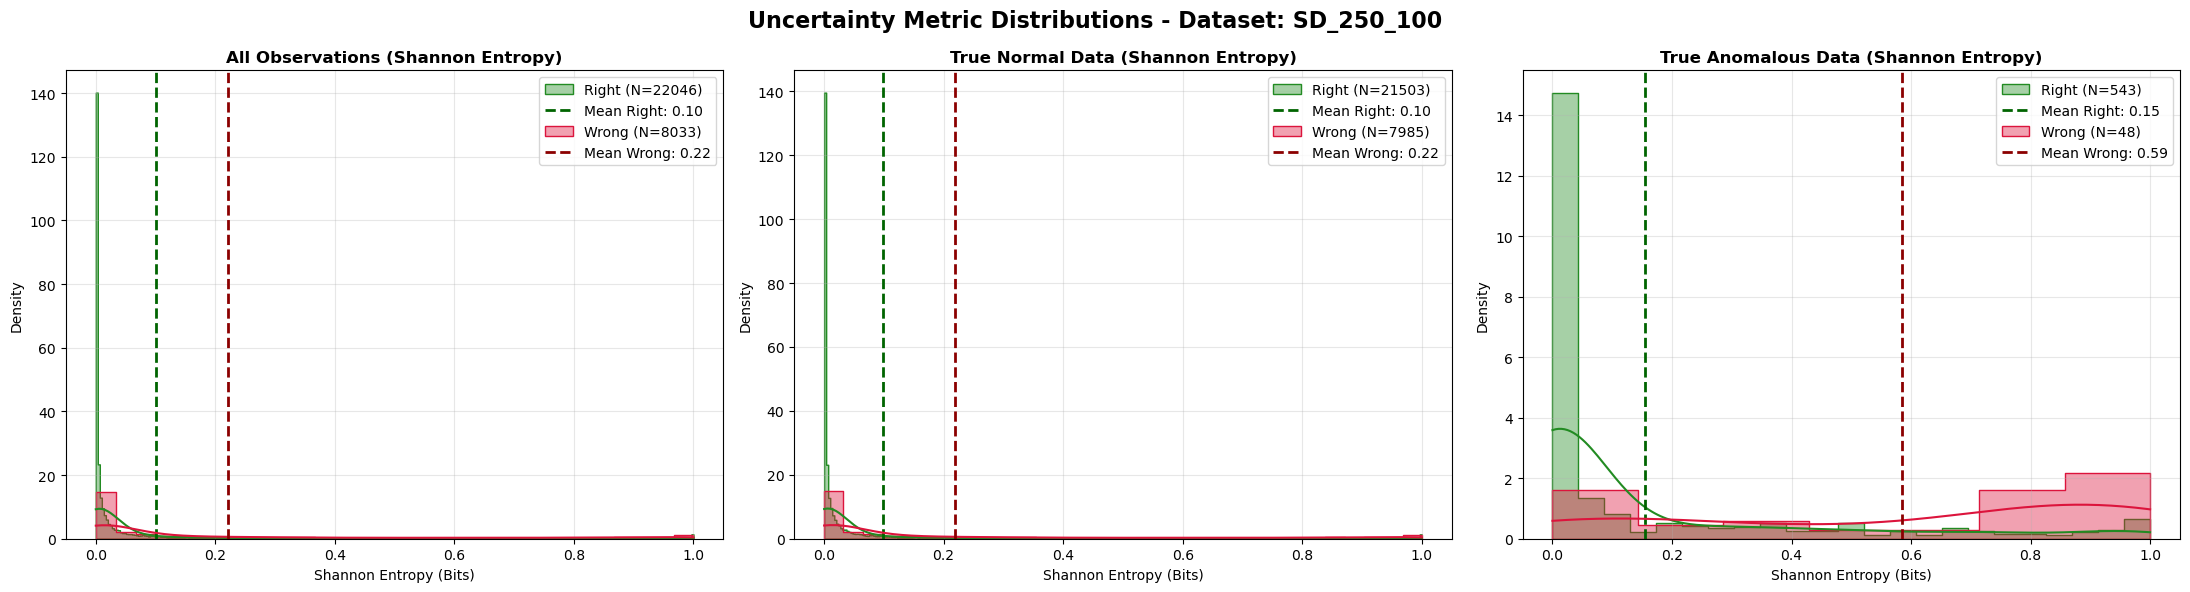

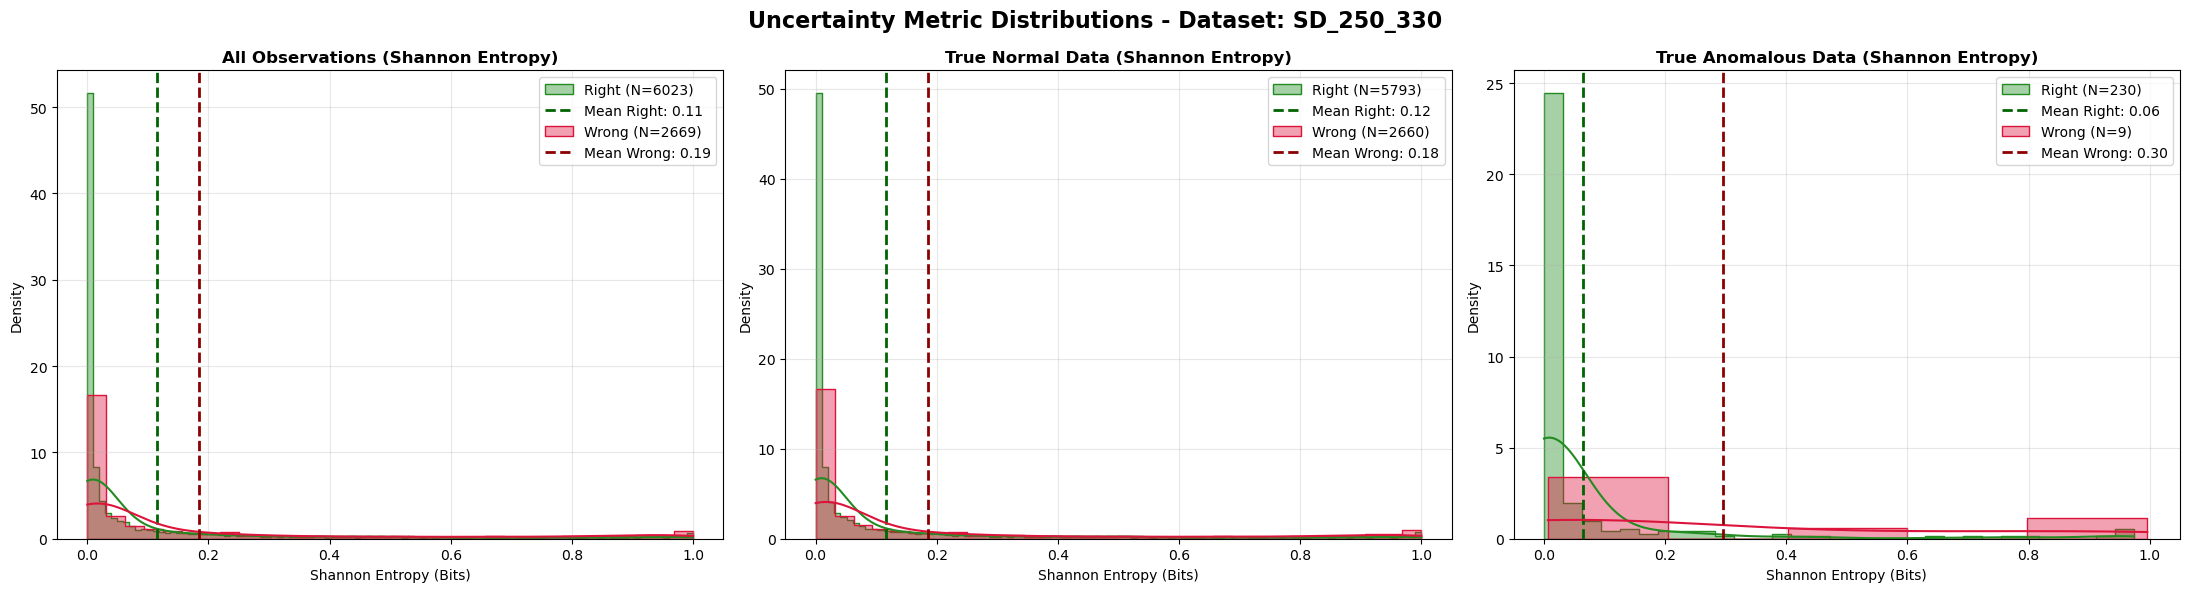

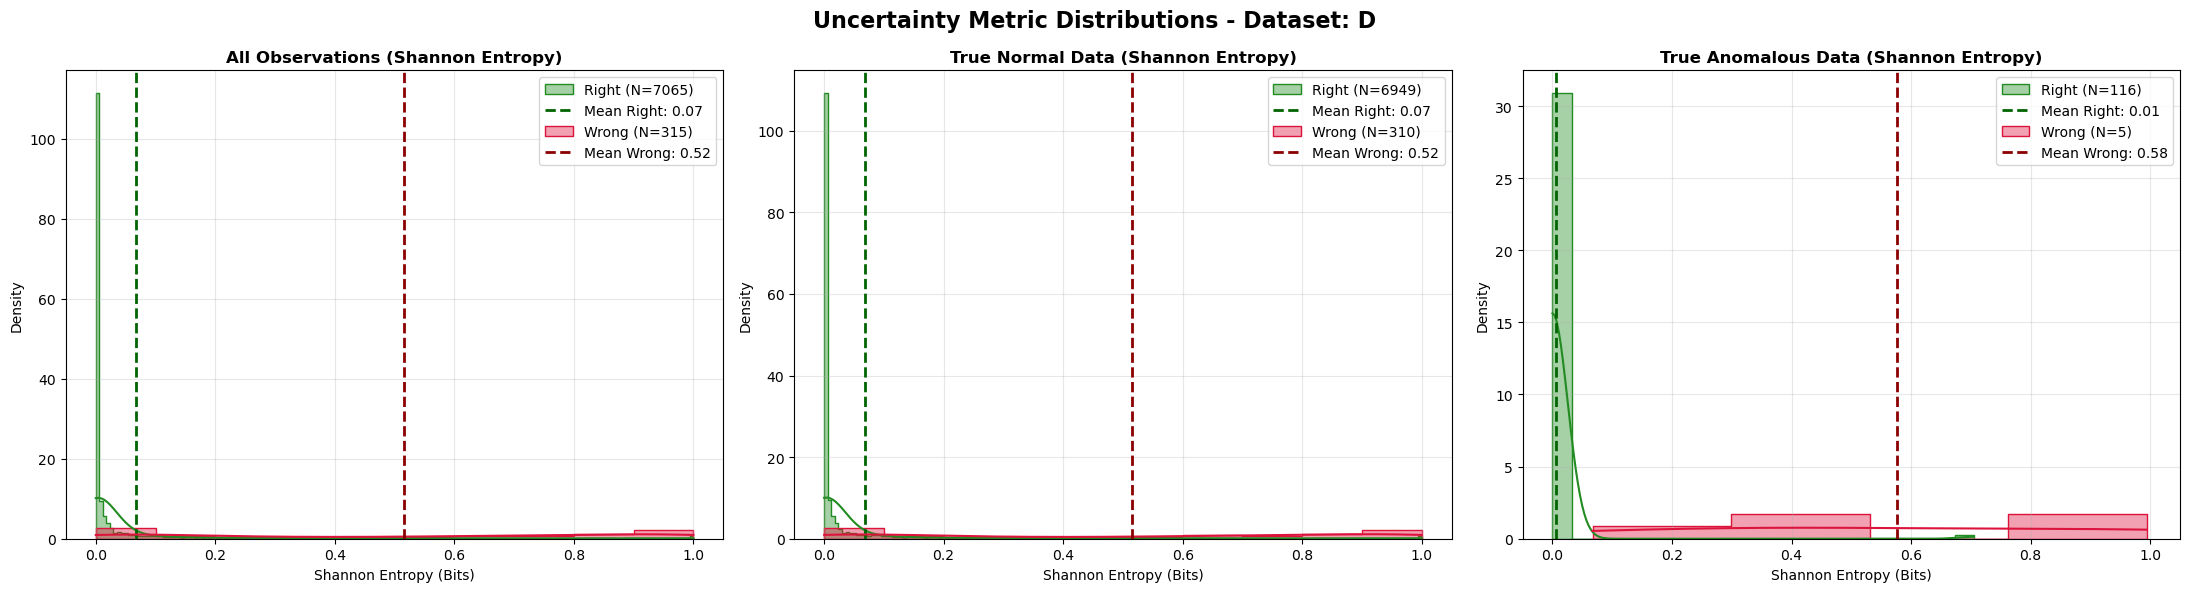

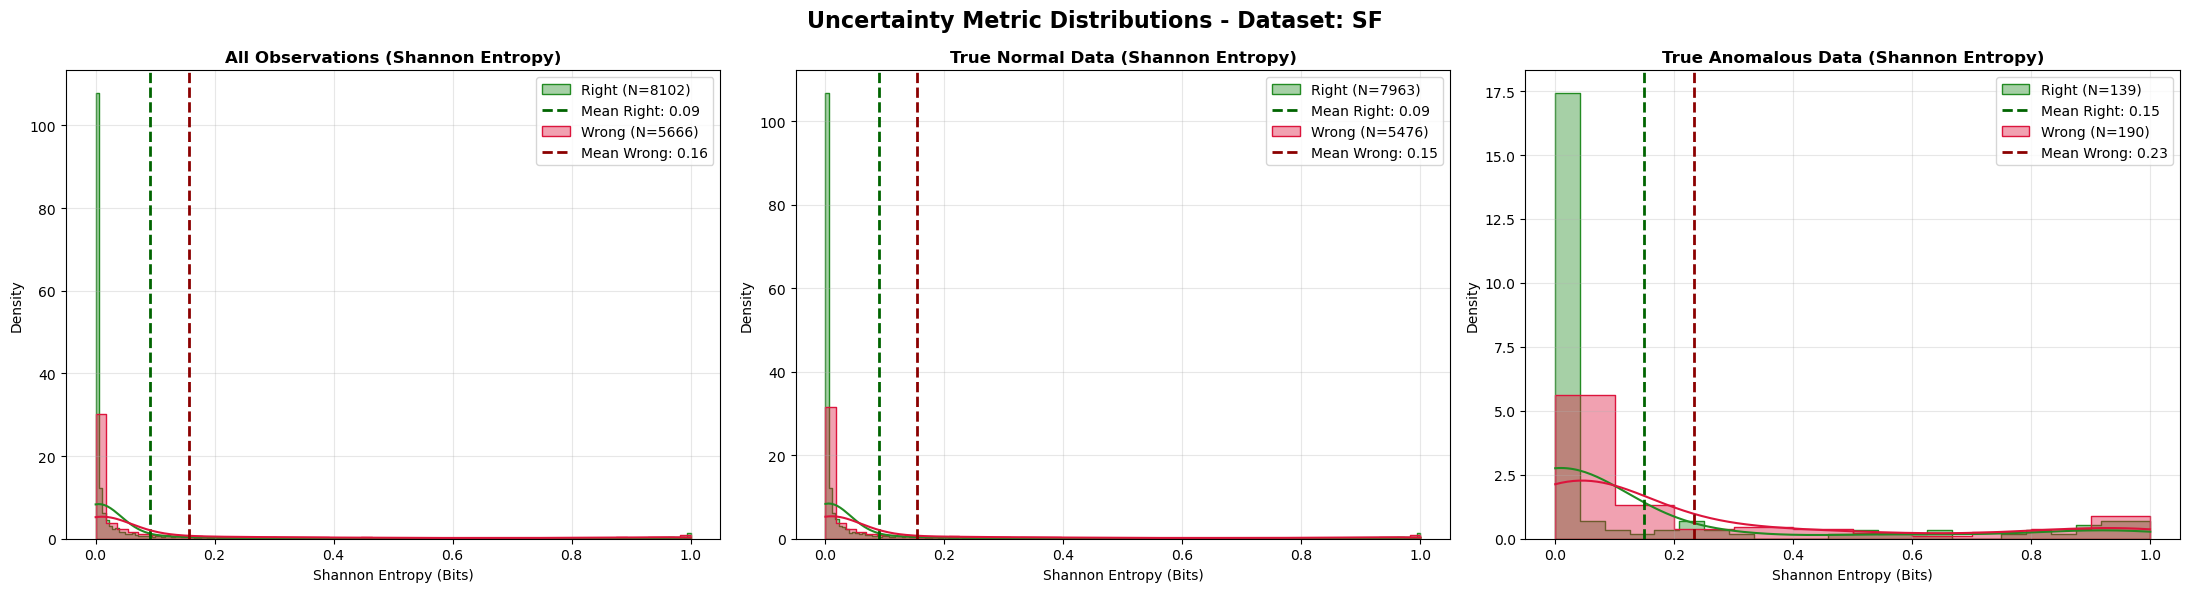

In [18]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader

T = 1.0

for operation, data in unseen_data.items():
    model.set_mode("classify")
    model.eval()

    eval_dataset = VibrationClassificationDataset(data["x_train"], data["y_train"])
    eval_loader = DataLoader(eval_dataset, batch_size=64, shuffle=False)

    all_preds = []
    all_labels = []
    all_energies = []
    all_entropies = []

    with torch.no_grad():
        for inputs, labels in eval_loader:
            logits = model(inputs)  # Get raw unnormalized logits

            # 1. Calculate energy scores
            energies = -T * torch.logsumexp(logits / T, dim=1)

            # 2. Calculate Shannon Entropy mathematically stably
            log_probs = F.log_softmax(logits, dim=1)
            probs = torch.exp(log_probs)
            # Entropy = - sum(p * log2(p)) -> convert natural log to log2 via division
            entropies = -torch.sum(probs * log_probs, dim=1) / np.log(2)

            # 3. Predictions
            _, predicted = torch.max(logits, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_energies.extend(energies.cpu().numpy())
            all_entropies.extend(entropies.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_energies = np.array(all_energies)
    all_entropies = np.array(all_entropies)

    # Save to your dictionary
    data["pseudo_labels"] = {
        "preds": all_preds,
        "labels": all_labels,
        "energies": all_energies,
        "entropies": all_entropies,
    }

    # --- Setup global masks for prediction outcomes ---
    correct_mask = all_preds == all_labels
    wrong_mask = all_preds != all_labels

    # Setup global masks for true classes (0 = good/normal, 1 = bad/anomalous)
    normal_mask = all_labels == 0
    anomalous_mask = all_labels == 1

    # Initialize the 1-row, 3-column figure canvas
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(
        f"Uncertainty Metric Distributions - Dataset: {operation}",
        fontsize=16,
        fontweight="bold",
    )

    # =========================================================================
    # COLUMN 1: All Observations (Energy Scores Overlay)
    # =========================================================================
    entropy_correct = all_entropies[correct_mask]
    entropy_wrong = all_entropies[wrong_mask]

    if len(entropy_correct) > 0:
        sns.histplot(
            entropy_correct,
            color="forestgreen",
            kde=True,
            element="step",
            stat="density",
            alpha=0.4,
            ax=axes[0],
            label=f"Right (N={len(entropy_correct)})",
        )
        axes[0].axvline(
            np.mean(entropy_correct),
            color="darkgreen",
            linestyle="--",
            linewidth=2,
            label=f"Mean Right: {np.mean(entropy_correct):.2f}",
        )
    if len(entropy_wrong) > 0:
        sns.histplot(
            entropy_wrong,
            color="crimson",
            kde=True,
            element="step",
            stat="density",
            alpha=0.4,
            ax=axes[0],
            label=f"Wrong (N={len(entropy_wrong)})",
        )
        axes[0].axvline(
            np.mean(entropy_wrong),
            color="darkred",
            linestyle="--",
            linewidth=2,
            label=f"Mean Wrong: {np.mean(entropy_wrong):.2f}",
        )

    axes[0].set_title(
        "All Observations (Shannon Entropy)", fontsize=12, fontweight="bold"
    )
    axes[0].set_xlabel("Shannon Entropy (Bits)")
    axes[0].set_ylabel("Density")
    axes[0].legend(loc="upper right")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(-0.05, 1.05)

    # =========================================================================
    # COLUMN 2: True Normal Data Only (Shannon Entropy Overlay)
    # =========================================================================
    entropy_normal_correct = all_entropies[normal_mask & correct_mask]
    entropy_normal_wrong = all_entropies[normal_mask & wrong_mask]

    if len(entropy_normal_correct) > 0:
        sns.histplot(
            entropy_normal_correct,
            color="forestgreen",
            kde=True,
            element="step",
            stat="density",
            alpha=0.4,
            ax=axes[1],
            label=f"Right (N={len(entropy_normal_correct)})",
        )
        axes[1].axvline(
            np.mean(entropy_normal_correct),
            color="darkgreen",
            linestyle="--",
            linewidth=2,
            label=f"Mean Right: {np.mean(entropy_normal_correct):.2f}",
        )
    if len(entropy_normal_wrong) > 0:
        sns.histplot(
            entropy_normal_wrong,
            color="crimson",
            kde=True,
            element="step",
            stat="density",
            alpha=0.4,
            ax=axes[1],
            label=f"Wrong (N={len(entropy_normal_wrong)})",
        )
        axes[1].axvline(
            np.mean(entropy_normal_wrong),
            color="darkred",
            linestyle="--",
            linewidth=2,
            label=f"Mean Wrong: {np.mean(entropy_normal_wrong):.2f}",
        )

    axes[1].set_title(
        "True Normal Data (Shannon Entropy)", fontsize=12, fontweight="bold"
    )
    axes[1].set_xlabel("Shannon Entropy (Bits)")
    axes[1].set_ylabel("Density")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(-0.05, 1.05)  # Shannon entropy bounding for binary classification

    # =========================================================================
    # COLUMN 3: True Anomalous Data Only (Shannon Entropy Overlay)
    # =========================================================================
    entropy_anomaly_correct = all_entropies[anomalous_mask & correct_mask]
    entropy_anomaly_wrong = all_entropies[anomalous_mask & wrong_mask]

    if len(entropy_anomaly_correct) > 0:
        sns.histplot(
            entropy_anomaly_correct,
            color="forestgreen",
            kde=True,
            element="step",
            stat="density",
            alpha=0.4,
            ax=axes[2],
            label=f"Right (N={len(entropy_anomaly_correct)})",
        )
        axes[2].axvline(
            np.mean(entropy_anomaly_correct),
            color="darkgreen",
            linestyle="--",
            linewidth=2,
            label=f"Mean Right: {np.mean(entropy_anomaly_correct):.2f}",
        )
    if len(entropy_anomaly_wrong) > 0:
        sns.histplot(
            entropy_anomaly_wrong,
            color="crimson",
            kde=True,
            element="step",
            stat="density",
            alpha=0.4,
            ax=axes[2],
            label=f"Wrong (N={len(entropy_anomaly_wrong)})",
        )
        axes[2].axvline(
            np.mean(entropy_anomaly_wrong),
            color="darkred",
            linestyle="--",
            linewidth=2,
            label=f"Mean Wrong: {np.mean(entropy_anomaly_wrong):.2f}",
        )

    axes[2].set_title(
        "True Anomalous Data (Shannon Entropy)", fontsize=12, fontweight="bold"
    )
    axes[2].set_xlabel("Shannon Entropy (Bits)")
    axes[2].set_ylabel("Density")
    axes[2].legend(loc="upper right")
    axes[2].grid(True, alpha=0.3)
    axes[2].set_xlim(-0.05, 1.05)

    plt.tight_layout()
    plt.show()


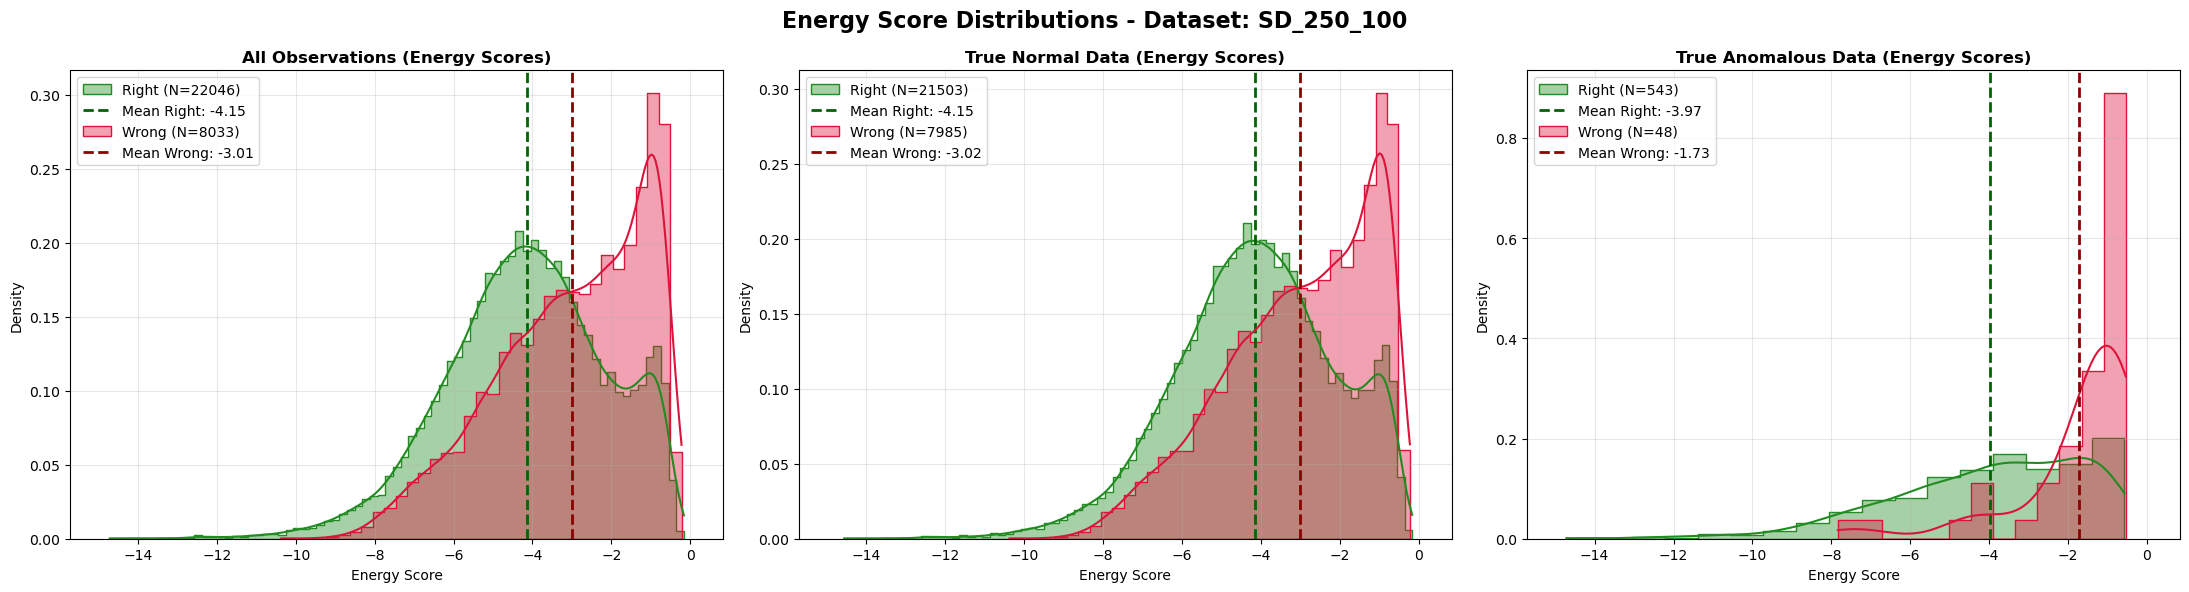

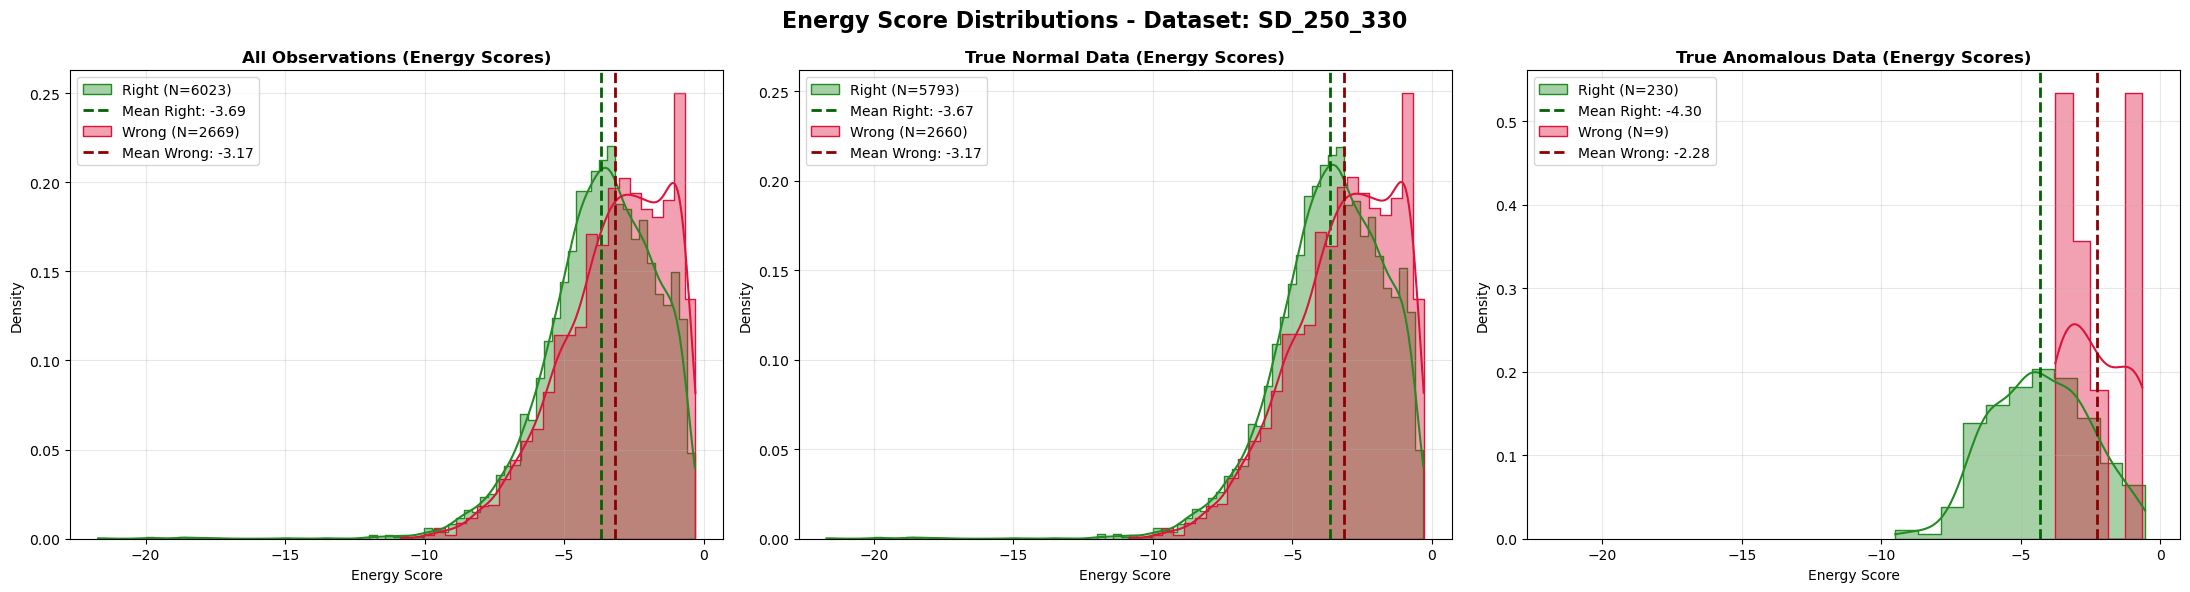

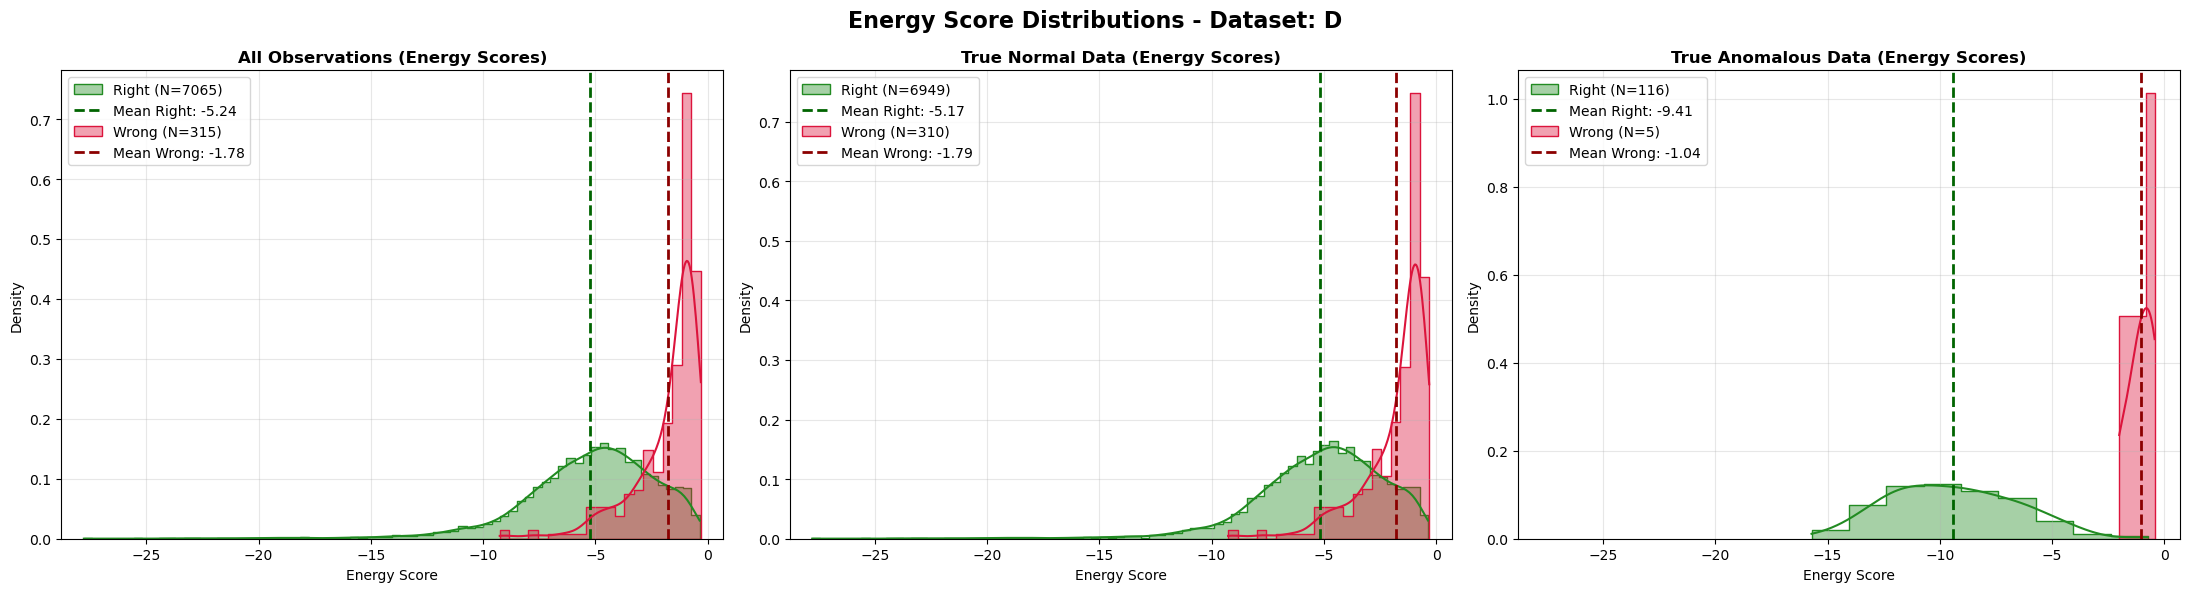

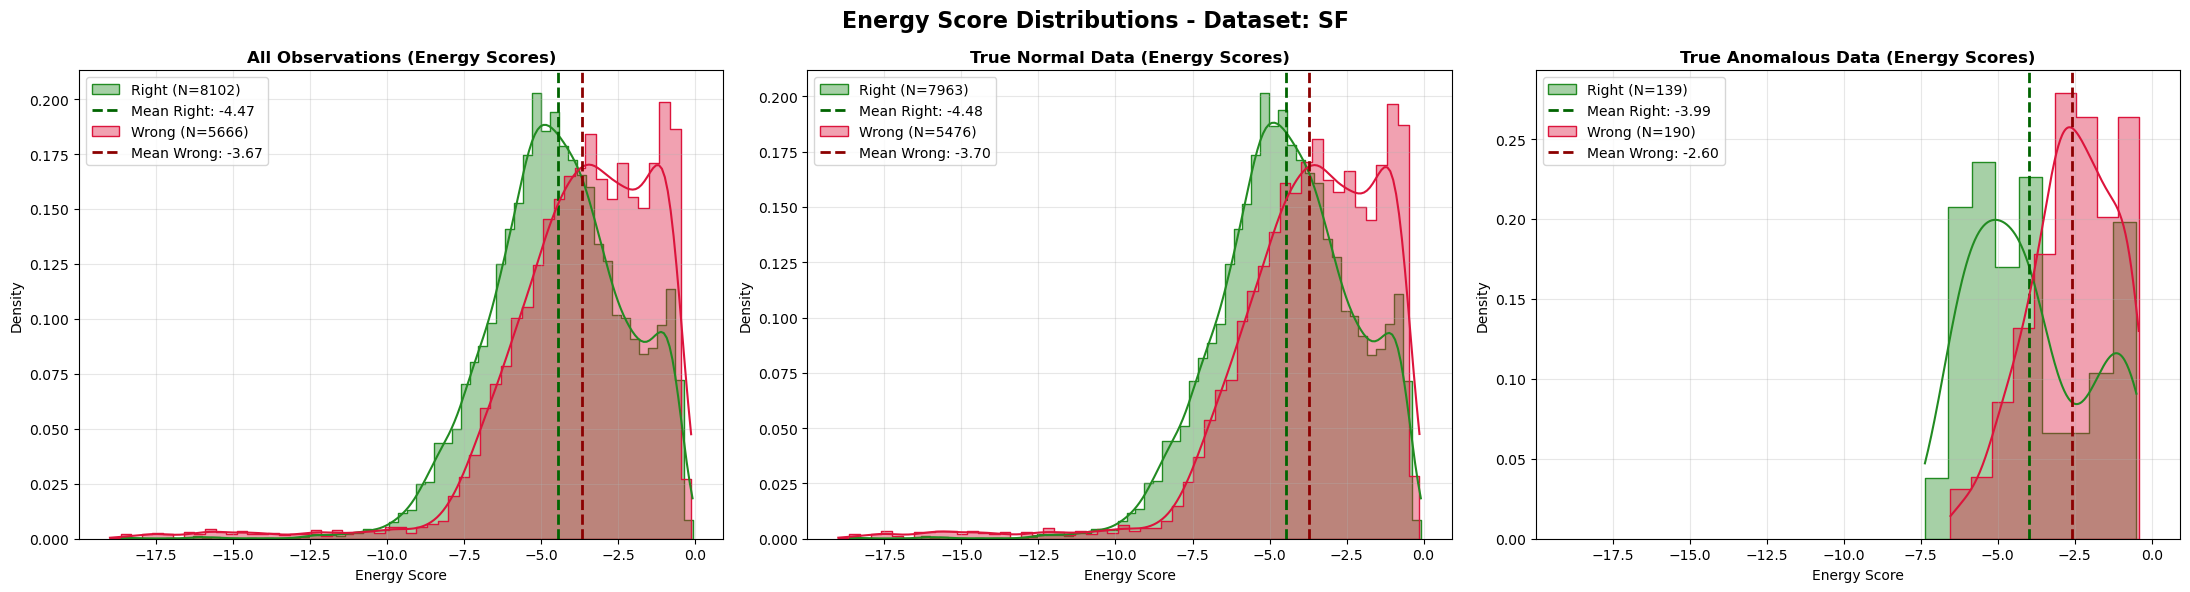

In [20]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader

T = 1.0

for operation, data in unseen_data.items():
    model.set_mode("classify")
    model.eval()

    eval_dataset = VibrationClassificationDataset(data["x_train"], data["y_train"])
    eval_loader = DataLoader(eval_dataset, batch_size=64, shuffle=False)

    all_preds = []
    all_labels = []
    all_energies = []

    with torch.no_grad():
        for inputs, labels in eval_loader:
            logits = model(inputs)  # Get raw unnormalized logits

            # Calculate Energy scores: -T * logsumexp(logits / T)
            energies = -T * torch.logsumexp(logits / T, dim=1)

            # Predictions
            _, predicted = torch.max(logits, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_energies.extend(energies.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_energies = np.array(all_energies)

    # Save to your dictionary
    data["pseudo_labels"] = {
        "preds": all_preds,
        "labels": all_labels,
        "energies": all_energies,
    }

    # --- Setup global masks for prediction outcomes ---
    correct_mask = all_preds == all_labels
    wrong_mask = all_preds != all_labels

    # Setup global masks for true classes (0 = good/normal, 1 = bad/anomalous)
    normal_mask = all_labels == 0
    anomalous_mask = all_labels == 1

    # Dynamically find a shared x-axis scale for this specific operation
    min_energy = np.min(all_energies) - 1.0
    max_energy = np.max(all_energies) + 1.0

    # Initialize the 1-row, 3-column figure canvas
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(
        f"Energy Score Distributions - Dataset: {operation}",
        fontsize=16,
        fontweight="bold",
    )

    # =========================================================================
    # COLUMN 1: All Observations (Energy Scores Overlay)
    # =========================================================================
    energies_correct = all_energies[correct_mask]
    energies_wrong = all_energies[wrong_mask]

    if len(energies_correct) > 0:
        sns.histplot(
            energies_correct,
            color="forestgreen",
            kde=True,
            element="step",
            stat="density",
            alpha=0.4,
            ax=axes[0],
            label=f"Right (N={len(energies_correct)})",
        )
        axes[0].axvline(
            np.mean(energies_correct),
            color="darkgreen",
            linestyle="--",
            linewidth=2,
            label=f"Mean Right: {np.mean(energies_correct):.2f}",
        )
    if len(energies_wrong) > 0:
        sns.histplot(
            energies_wrong,
            color="crimson",
            kde=True,
            element="step",
            stat="density",
            alpha=0.4,
            ax=axes[0],
            label=f"Wrong (N={len(energies_wrong)})",
        )
        axes[0].axvline(
            np.mean(energies_wrong),
            color="darkred",
            linestyle="--",
            linewidth=2,
            label=f"Mean Wrong: {np.mean(energies_wrong):.2f}",
        )

    axes[0].set_title(
        "All Observations (Energy Scores)", fontsize=12, fontweight="bold"
    )
    axes[0].set_xlabel("Energy Score")
    axes[0].set_ylabel("Density")
    axes[0].legend(loc="upper left")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(min_energy, max_energy)

    # =========================================================================
    # COLUMN 2: True Normal Data Only (Energy Scores Overlay)
    # =========================================================================
    energies_normal_correct = all_energies[normal_mask & correct_mask]
    energies_normal_wrong = all_energies[normal_mask & wrong_mask]

    if len(energies_normal_correct) > 0:
        sns.histplot(
            energies_normal_correct,
            color="forestgreen",
            kde=True,
            element="step",
            stat="density",
            alpha=0.4,
            ax=axes[1],
            label=f"Right (N={len(energies_normal_correct)})",
        )
        axes[1].axvline(
            np.mean(energies_normal_correct),
            color="darkgreen",
            linestyle="--",
            linewidth=2,
            label=f"Mean Right: {np.mean(energies_normal_correct):.2f}",
        )
    if len(energies_normal_wrong) > 0:
        sns.histplot(
            energies_normal_wrong,
            color="crimson",
            kde=True,
            element="step",
            stat="density",
            alpha=0.4,
            ax=axes[1],
            label=f"Wrong (N={len(energies_normal_wrong)})",
        )
        axes[1].axvline(
            np.mean(energies_normal_wrong),
            color="darkred",
            linestyle="--",
            linewidth=2,
            label=f"Mean Wrong: {np.mean(energies_normal_wrong):.2f}",
        )

    axes[1].set_title(
        "True Normal Data (Energy Scores)", fontsize=12, fontweight="bold"
    )
    axes[1].set_xlabel("Energy Score")
    axes[1].set_ylabel("Density")
    axes[1].legend(loc="upper left")
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(min_energy, max_energy)

    # =========================================================================
    # COLUMN 3: True Anomalous Data Only (Energy Scores Overlay)
    # =========================================================================
    energies_anomaly_correct = all_energies[anomalous_mask & correct_mask]
    energies_anomaly_wrong = all_energies[anomalous_mask & wrong_mask]

    if len(energies_anomaly_correct) > 0:
        sns.histplot(
            energies_anomaly_correct,
            color="forestgreen",
            kde=True,
            element="step",
            stat="density",
            alpha=0.4,
            ax=axes[2],
            label=f"Right (N={len(energies_anomaly_correct)})",
        )
        axes[2].axvline(
            np.mean(energies_anomaly_correct),
            color="darkgreen",
            linestyle="--",
            linewidth=2,
            label=f"Mean Right: {np.mean(energies_anomaly_correct):.2f}",
        )
    if len(energies_anomaly_wrong) > 0:
        sns.histplot(
            energies_anomaly_wrong,
            color="crimson",
            kde=True,
            element="step",
            stat="density",
            alpha=0.4,
            ax=axes[2],
            label=f"Wrong (N={len(energies_anomaly_wrong)})",
        )
        axes[2].axvline(
            np.mean(energies_anomaly_wrong),
            color="darkred",
            linestyle="--",
            linewidth=2,
            label=f"Mean Wrong: {np.mean(energies_anomaly_wrong):.2f}",
        )

    axes[2].set_title(
        "True Anomalous Data (Energy Scores)", fontsize=12, fontweight="bold"
    )
    axes[2].set_xlabel("Energy Score")
    axes[2].set_ylabel("Density")
    axes[2].legend(loc="upper left")
    axes[2].grid(True, alpha=0.3)
    axes[2].set_xlim(min_energy, max_energy)

    plt.tight_layout()
    plt.show()
